# Sudan Climate EDA
Exploratory Data Analysis of Sudan's climate dataset as part of the 10 Academy Week 0 challenge.

The dataset contains daily climate records from 2015 to 2026. Key columns include:
- **T2M**: Temperature at 2 meters (°C)
- **T2M_MAX / T2M_MIN**: Daily max and min temperature
- **PRECTOTCORR**: Precipitation (mm)
- **RH2M**: Relative humidity at 2 meters (%)
- **WS2M**: Wind speed at 2 meters (m/s)
- **PS**: Surface pressure
- **QV2M**: Specific humidity
- **DOY**: Day of year

## 1. Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data
Load the Sudan climate dataset and preview the first few rows.

In [8]:
df = pd.read_csv('../data/sudan.csv', sep='\t')
df['Country'] = 'Sudan'
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


## 3. Data Overview
Check summary statistics and missing values.

In [9]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000


In [10]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64

## 4. Data Cleaning
Replace sentinel value -999 with NaN, remove duplicate rows, and forward-fill missing values.

In [11]:
df.replace(-999, np.nan, inplace=True)
df.drop_duplicates(inplace=True)
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan


## 5. Feature Engineering
Create a proper date column from YEAR and DOY, then extract the Month for seasonal analysis.

In [12]:
df['date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['date'].dt.month

## 6. Visualizations
Explore seasonal patterns in temperature, rainfall, and correlations between climate variables.

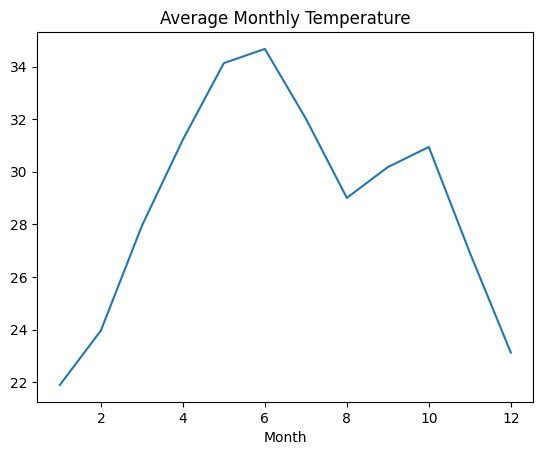

In [13]:
monthly_temp = df.groupby('Month')['T2M'].mean()
monthly_temp.plot()
plt.title('Average Monthly Temperature')
plt.show()

Sudan has an arid to semi-arid climate with very high temperatures, especially in the north. Temperatures peak between April–June (often exceeding 40°C) and are cooler from November–February.

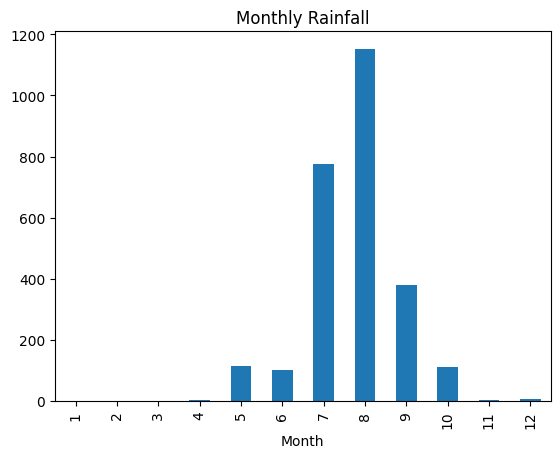

In [14]:
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum()
monthly_rain.plot(kind='bar')
plt.title('Monthly Rainfall')
plt.show()

Sudan receives most of its rainfall during the summer monsoon season (July–September), particularly in the south. The north is largely desert with very little annual rainfall.

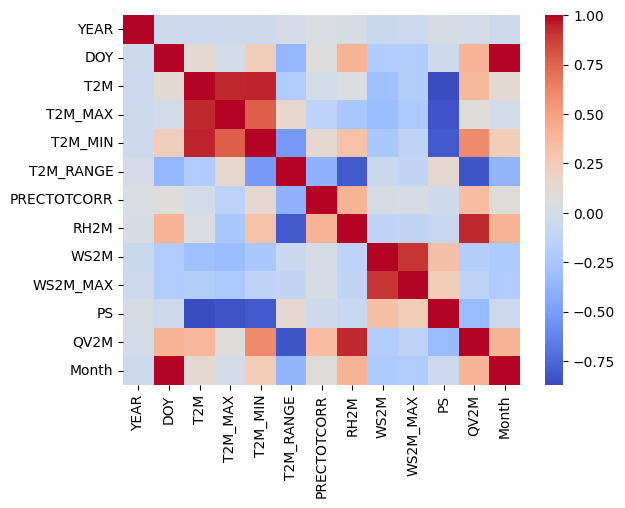

In [15]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

The heatmap shows strong positive correlations between T2M, T2M_MAX, and T2M_MIN. Month correlates with rainfall (PRECTOTCORR), reflecting Sudan's concentrated summer rainy season.

## 7. Export Clean Data
Save the cleaned dataset for use in further analysis.

In [16]:
df.to_csv('../data/sudan_clean.csv', index=False)